In [2]:
import numpy as np
import pandas as pd
import hvplot.pandas
import matplotlib.pyplot as plt


In [3]:
k = 3
d = pd.read_hdf("output/meta-llama_Meta-Llama-3.1-8B-Instruct/d_r.h5")
rho = pd.read_hdf("output/meta-llama_Meta-Llama-3.1-8B-Instruct/rho_d.h5")
s = d - rho - np.log(k)

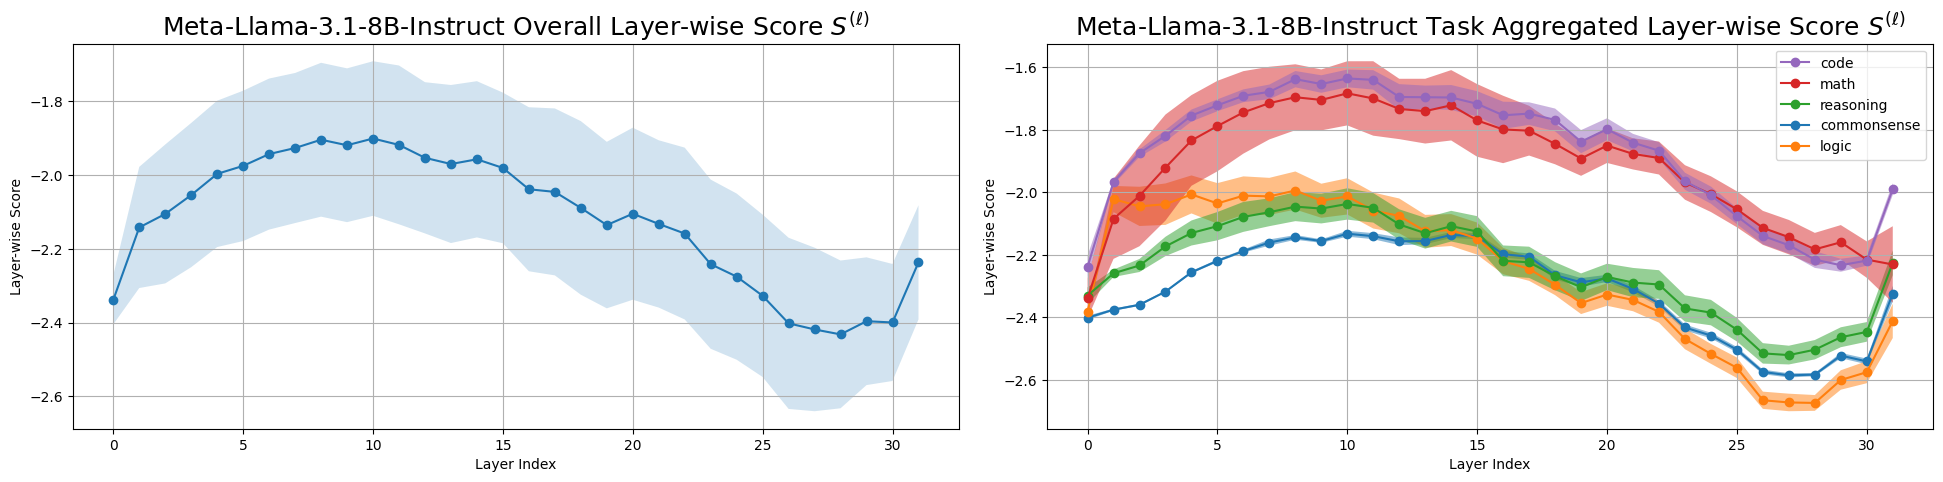

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(24,5))
all_s = s.to_numpy()
mean_s = np.mean(all_s, axis=1)
std_s = np.std(all_s, axis=1)
layer_indices = list(range(len(mean_s)))
ax[0].plot(layer_indices, mean_s, marker="o", linestyle="-", label="Mean")
ax[0].fill_between(
    layer_indices,
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.2,
    label="Std. Dev.",
)
ax[0].grid()
ax[0].set_title(r"Meta-Llama-3.1-8B-Instruct Overall Layer-wise Score $S^{(\ell)}$", fontsize=18)
ax[0].set_xlabel("Layer Index")
ax[0].set_ylabel("Layer-wise Score")

data = s.to_dict()
keys, vals = [k for k in data.keys()], np.array([[entry for entry in row.values()] for row in data.values()])
colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))

# display(vals, data.values())

# vals[:5].std(axis=0).shape
# vals[:5].mean(axis=0).shape

for i in range(0, len(keys), 5):
    task = keys[i].split("-")[0]
    task_vals = vals[i:i+5]
    mean_s, std_s = task_vals.mean(axis=0), task_vals.std(axis=0)
    ax[1].plot(layer_indices, mean_s, marker="o", linestyle="-", label=task)
    ax[1].fill_between(
        layer_indices,
        mean_s - std_s,
        mean_s + std_s,
        alpha=0.5,
    )

handles, labels = ax[1].get_legend_handles_labels()
order = [4, 3, 2, 0, 1]
ax[1].grid()
ax[1].legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right")
ax[1].set_title(r"Meta-Llama-3.1-8B-Instruct Task Aggregated Layer-wise Score $S^{(\ell)}$", fontsize=18)
ax[1].set_xlabel("Layer Index")
ax[1].set_ylabel("Layer-wise Score")

plt.subplots_adjust(wspace=0.1)
# plt.suptitle()
plt.show()
fig.savefig("output/score_revised.pdf", bbox_inches="tight")

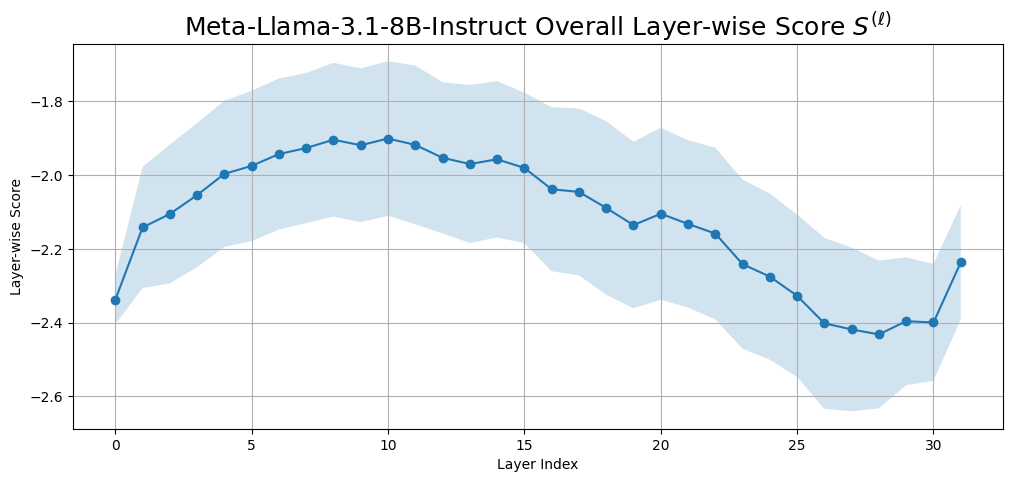

In [ ]:

plt.figure(figsize=(12,5))
all_s = s.to_numpy()
mean_s = np.mean(all_s, axis=1)
std_s = np.std(all_s, axis=1)
layer_indices = list(range(len(mean_s)))
plt.plot(layer_indices, mean_s, marker="o", linestyle="-", label="Mean")
plt.fill_between(
    layer_indices,
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.2,
    label="Std. Dev.",
)
plt.grid()
plt.title(r"Meta-Llama-3.1-8B-Instruct Overall Layer-wise Score $S^{(\ell)}$", fontsize=18)
plt.xlabel("Layer Index")
plt.ylabel("Layer-wise Score")
plt.savefig("output/overall.pdf", bbox_inches="tight")

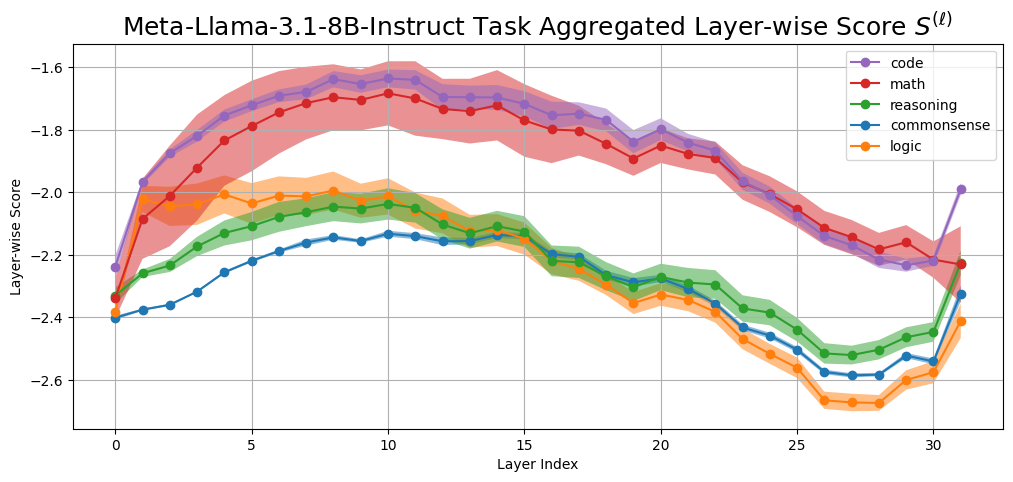

In [18]:
plt.figure(figsize=(12,5))
data = s.to_dict()
keys, vals = [k for k in data.keys()], np.array([[entry for entry in row.values()] for row in data.values()])
colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))

# display(vals, data.values())

# vals[:5].std(axis=0).shape
# vals[:5].mean(axis=0).shape

for i in range(0, len(keys), 5):
    task = keys[i].split("-")[0]
    task_vals = vals[i:i+5]
    mean_s, std_s = task_vals.mean(axis=0), task_vals.std(axis=0)
    plt.plot(layer_indices, mean_s, marker="o", linestyle="-", label=task)
    plt.fill_between(
        layer_indices,
        mean_s - std_s,
        mean_s + std_s,
        alpha=0.5,
    )

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
order = [4, 3, 2, 0, 1]
plt.grid()
plt.legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right")
plt.title(r"Meta-Llama-3.1-8B-Instruct Task Aggregated Layer-wise Score $S^{(\ell)}$", fontsize=18)
plt.xlabel("Layer Index")
plt.ylabel("Layer-wise Score")

# plt.suptitle()
plt.savefig("output/agg.pdf", bbox_inches="tight")
plt.show()

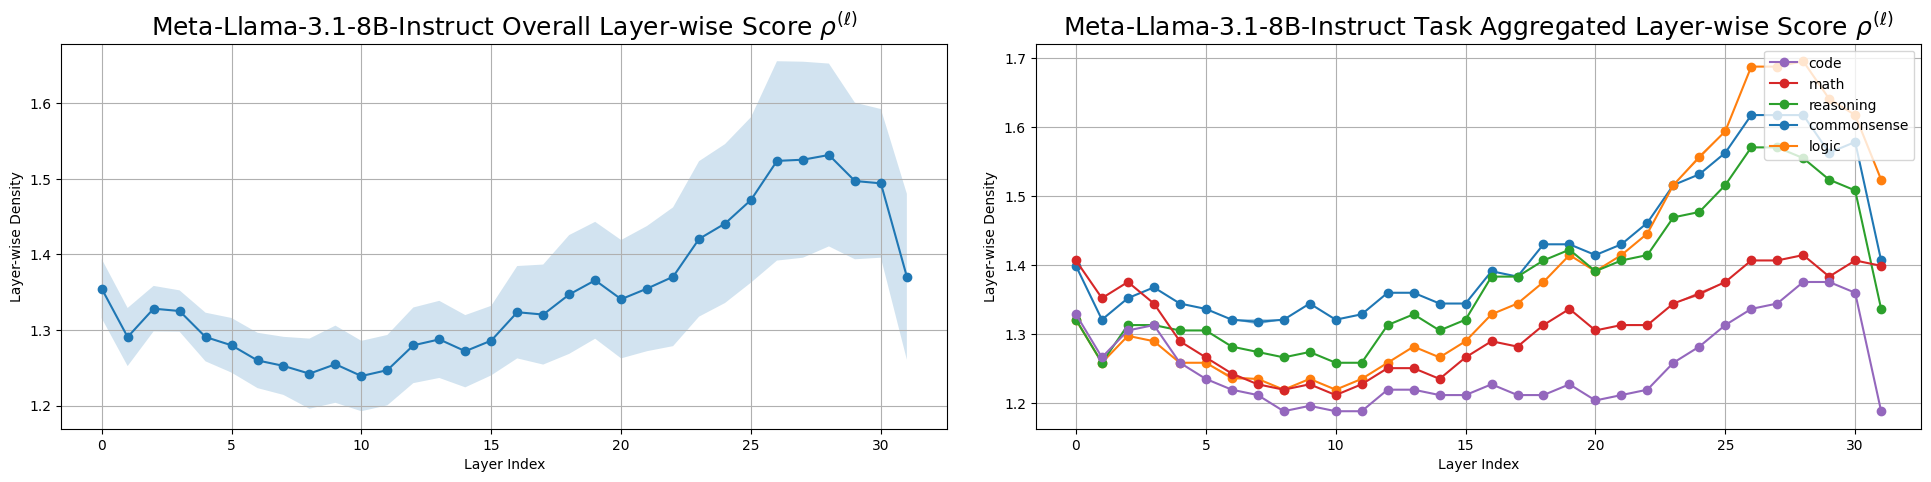

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(24,5))
all_rho = rho.to_numpy()
mean_rho = np.mean(all_rho, axis=1)
std_rho = np.std(all_rho, axis=1)
layer_indices = list(range(len(mean_rho)))
ax[0].plot(layer_indices, mean_rho, marker="o", linestyle="-", label="Mean")
ax[0].fill_between(
    layer_indices,
    mean_rho - std_rho,
    mean_rho + std_rho,
    alpha=0.2,
    label="Std. Dev.",
)
ax[0].grid()
ax[0].set_title(r"Meta-Llama-3.1-8B-Instruct Overall Layer-wise Score $\rho^{(\ell)}$", fontsize=18)
ax[0].set_xlabel("Layer Index")
ax[0].set_ylabel("Layer-wise Density")

data = rho.to_dict()
keys, vals = [k for k in data.keys()], np.array([[entry for entry in row.values()] for row in data.values()])
colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))

# display(vals, data.values())

# vals[:5].std(axis=0).shape
# vals[:5].mean(axis=0).shape

for i in range(0, len(keys), 5):
    task = keys[i].split("-")[0]
    task_vals = vals[i:i+5]
    mean_rho, std_rho = task_vals.mean(axis=0), task_vals.std(axis=0)
    ax[1].plot(layer_indices, mean_rho, marker="o", linestyle="-", label=task)
    ax[1].fill_between(
        layer_indices,
        mean_rho - std_rho,
        mean_rho + std_rho,
        alpha=0.5,
    )

handles, labels = ax[1].get_legend_handles_labels()
order = [4, 3, 2, 0, 1]
ax[1].grid()
ax[1].legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right")
ax[1].set_title(r"Meta-Llama-3.1-8B-Instruct Task Aggregated Layer-wise Score $\rho^{(\ell)}$", fontsize=18)
ax[1].set_xlabel("Layer Index")
ax[1].set_ylabel("Layer-wise Density")

plt.subplots_adjust(wspace=0.1)
# plt.suptitle()
plt.show()
fig.savefig("output/rho.pdf", bbox_inches="tight")

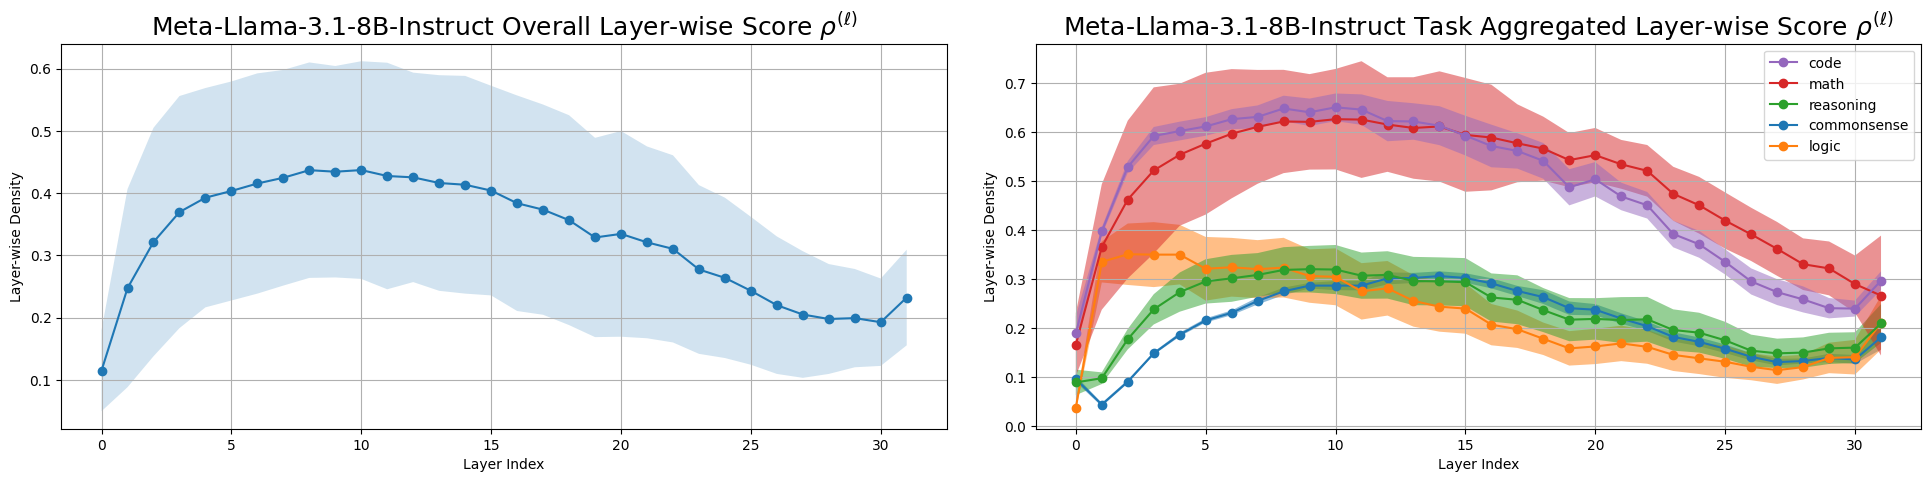

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(24,5))
all_dr = d.to_numpy()
mean_dr = np.mean(all_dr, axis=1)
std_dr = np.std(all_dr, axis=1)
layer_indices = list(range(len(mean_dr)))
ax[0].plot(layer_indices, mean_dr, marker="o", linestyle="-", label="Mean")
ax[0].fill_between(
    layer_indices,
    mean_dr - std_dr,
    mean_dr + std_dr,
    alpha=0.2,
    label="Std. Dev.",
)
ax[0].grid()
ax[0].set_title(r"Meta-Llama-3.1-8B-Instruct Overall Layer-wise Score $\rho^{(\ell)}$", fontsize=18)
ax[0].set_xlabel("Layer Index")
ax[0].set_ylabel("Layer-wise Density")

data = d.to_dict()
keys, vals = [k for k in data.keys()], np.array([[entry for entry in row.values()] for row in data.values()])
colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))

# display(vals, data.values())

# vals[:5].std(axis=0).shape
# vals[:5].mean(axis=0).shape

for i in range(0, len(keys), 5):
    task = keys[i].split("-")[0]
    task_vals = vals[i:i+5]
    mean_dr, std_dr = task_vals.mean(axis=0), task_vals.std(axis=0)
    ax[1].plot(layer_indices, mean_dr, marker="o", linestyle="-", label=task)
    ax[1].fill_between(
        layer_indices,
        mean_dr - std_dr,
        mean_dr + std_dr,
        alpha=0.5,
    )

handles, labels = ax[1].get_legend_handles_labels()
order = [4, 3, 2, 0, 1]
ax[1].grid()
ax[1].legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right")
ax[1].set_title(r"Meta-Llama-3.1-8B-Instruct Task Aggregated Layer-wise Score $\rho^{(\ell)}$", fontsize=18)
ax[1].set_xlabel("Layer Index")
ax[1].set_ylabel("Layer-wise Density")

plt.subplots_adjust(wspace=0.1)
# plt.suptitle()
plt.show()
fig.savefig("output/dr.pdf", bbox_inches="tight")

In [29]:
# s.to_numpy().shape
# # for each column (task) find max layer s
smax = s.max(axis=0)
# smax.shape
display(smax.mean(), smax.std())

np.float64(-1.8957997886681097)

np.float64(0.21127155743217718)

In [31]:
L, _ = s.shape
ausn = 1/L * s.sum()
display(ausn.mean(), ausn.std())

np.float64(-2.11938865585561)

np.float64(0.19754994553075475)

In [36]:
lmax = np.argmax(s, axis=0)

display(np.median(lmax), np.percentile(s, 75) - np.percentile(s, 25))

np.float64(10.0)

np.float64(0.3837890625000002)